# Blueberry yield ML project

The task is to use regression to predict the yield of wild blueberries.
teach a machine learning model the relationship between the features and the yield.




In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [ ]:
train = pd.read_csv("C:\\Users\\HAZEL\\Desktop\\Machine_Learning\\data\\train.csv")
train.head()


,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
0,0,25.0,0.50,0.25,0.75,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146
1,1,25.0,0.50,0.25,0.50,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201
2,2,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760
3,3,12.5,0.25,0.25,0.63,0.50,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590
4,4,25.0,0.50,0.25,0.63,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417


In [49]:
test = pd.read_csv(r"C:\Users\HAZEL\Desktop\Machine_Learning\data\test.csv")
test.head()


,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds
0,15289,25.0,0.25,0.25,0.25,0.25,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.399367,0.408088,31.394569
1,15290,12.5,0.25,0.25,0.75,0.63,94.6,57.2,79.0,68.2,33.0,55.9,1.0,0.10,0.488048,0.442866,36.846956
2,15291,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.583379,0.487057,40.037644
3,15292,25.0,0.50,0.38,0.38,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.433014,0.422847,33.116091
4,15293,37.5,0.75,0.25,0.25,0.25,94.6,57.2,79.0,68.2,33.0,55.9,24.0,0.39,0.360996,0.388860,29.558019


## Exploratory Data Analysis

In [24]:
train.info() # checking the data types

<class 'pandas.DataFrame'>
RangeIndex: 15289 entries, 0 to 15288
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    15289 non-null  int64  
 1   clonesize             15289 non-null  float64
 2   honeybee              15289 non-null  float64
 3   bumbles               15289 non-null  float64
 4   andrena               15289 non-null  float64
 5   osmia                 15289 non-null  float64
 6   MaxOfUpperTRange      15289 non-null  float64
 7   MinOfUpperTRange      15289 non-null  float64
 8   AverageOfUpperTRange  15289 non-null  float64
 9   MaxOfLowerTRange      15289 non-null  float64
 10  MinOfLowerTRange      15289 non-null  float64
 11  AverageOfLowerTRange  15289 non-null  float64
 12  RainingDays           15289 non-null  float64
 13  AverageRainingDays    15289 non-null  float64
 14  fruitset              15289 non-null  float64
 15  fruitmass             15289 no

In [25]:
train.describe()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
count,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000
mean,7644.000000,19.704690,0.389314,0.286768,0.492675,0.592355,82.169887,49.673281,68.656256,59.229538,28.660553,48.568500,18.660865,0.324176,0.502741,0.446553,36.164950,6025.193999
std,4413.698468,6.595211,0.361643,0.059917,0.148115,0.139489,9.146703,5.546405,7.641807,6.610640,3.195367,5.390545,11.657582,0.163905,0.074390,0.037035,4.031087,1337.056850
min,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,69.700000,39.000000,58.200000,50.200000,24.300000,41.200000,1.000000,0.060000,0.192732,0.311921,22.079199,1945.530610
25%,3822.000000,12.500000,0.250000,0.250000,0.380000,0.500000,77.400000,46.800000,64.700000,55.800000,27.000000,45.800000,16.000000,0.260000,0.458246,0.419216,33.232449,5128.163510
50%,7644.000000,25.000000,0.500000,0.250000,0.500000,0.630000,86.000000,52.000000,71.900000,62.000000,30.000000,50.800000,16.000000,0.260000,0.506600,0.446570,36.040675,6117.475900
75%,11466.000000,25.000000,0.500000,0.380000,0.630000,0.750000,86.000000,52.000000,71.900000,62.000000,30.000000,50.800000,24.000000,0.390000,0.560445,0.474134,39.158238,7019.694380
max,15288.000000,40.000000,18.430000,0.585000,0.750000,0.750000,94.600000,57.200000,79.000000,68.200000,33.000000,55.900000,34.000000,0.560000,0.652144,0.535660,46.585105,8969.401840


In [26]:
# check for missing values
train.isnull().sum()

id                      0
clonesize               0
honeybee                0
bumbles                 0
andrena                 0
osmia                   0
MaxOfUpperTRange        0
MinOfUpperTRange        0
AverageOfUpperTRange    0
MaxOfLowerTRange        0
MinOfLowerTRange        0
AverageOfLowerTRange    0
RainingDays             0
AverageRainingDays      0
fruitset                0
fruitmass               0
seeds                   0
yield                   0
dtype: int64

In [27]:
train.duplicated().sum()

np.int64(0)

In [28]:
train = train.drop_duplicates()

In [29]:
train.shape

(15289, 18)

## Check the distribution

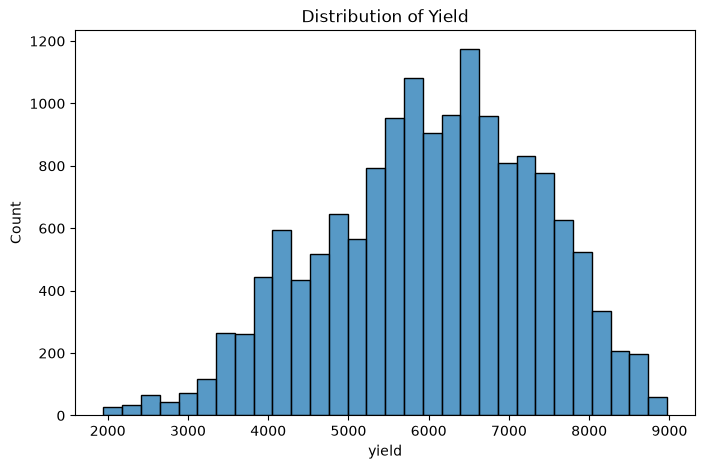

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(train["yield"], bins=30) # divides the yield values into 30 bars/intervals

plt.title("Distribution of Yield")

plt.show()

The distribution is slightly skewed to the left, most yields are clustered around 6000, farms with unusually low yields on the left the yield values are approximately normally distributed

## correlation matrix

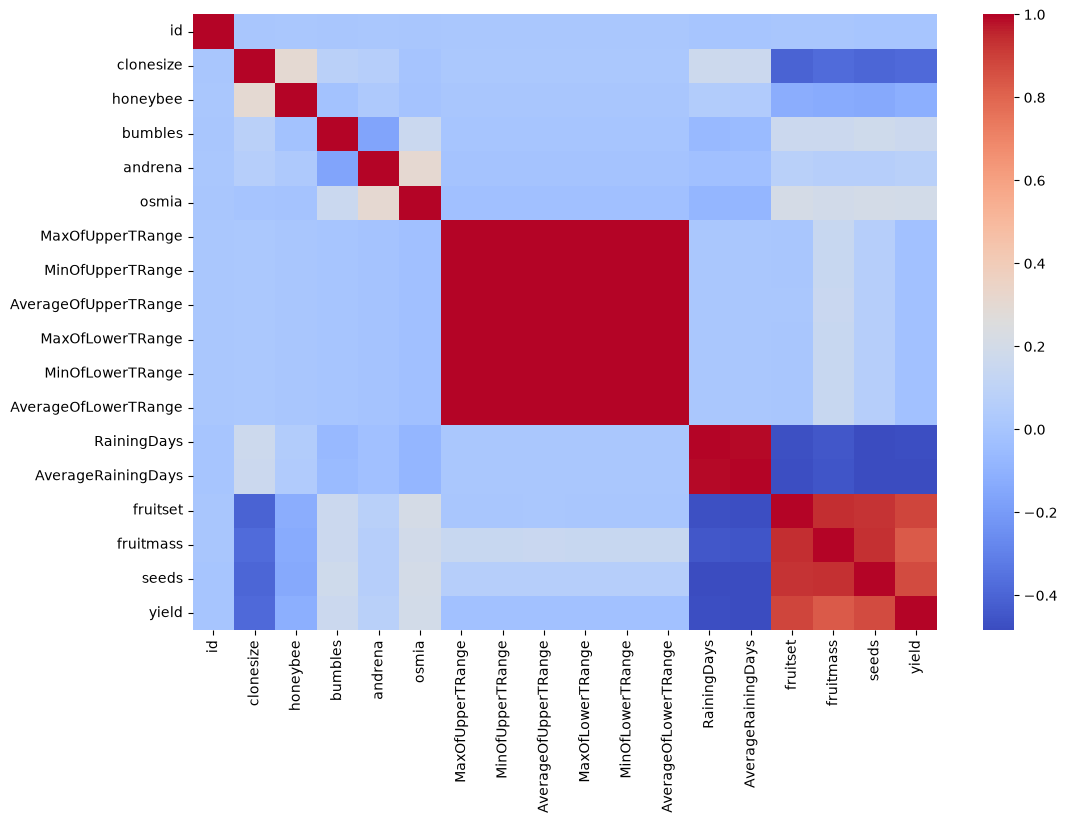

In [31]:
plt.figure(figsize=(12,8)) # sets the size

""""
 This calculates the correlation matrix for all numeric columns in train showshow strongly each variables is related 
 to every other numeric variable
"""
corr = train.corr(numeric_only=True) 

sns.heatmap(corr, cmap="coolwarm") # draws the matrix as a clorored heatmap

plt.show() # red +ve correlation blue -ve corrrelation

fruitset, fruitmass, seeds have a strong positive correlation to yield
raining days , averagerainingdays and clone size have a moderately negative correlation to yield
fruitset is likely an important predictor

## seperate and split the data

In [39]:
# remove id column cause it does not affect yield
X = train.drop(["id","yield"] , axis=1)

y = train["yield"]


In [58]:
X_test = test.drop("id", axis=1)

In [ ]:
#splits the dataset into two - helps us learn whether the model has learned petterns or just 
# memorised the training data
from sklearn.model_selection import train_test_split

# X_train - what the model studies ,  Y_train - answers for X_train
# X_valid - features the model has never seen , Y_valid - correct answers
X_train, X_valid, y_train, y_valid = train_test_split(
    
    X, # use all the feature columns
    y, # use the target column
    test_size=0.2, # this tells python 20% validation/test 80% training
    random_state=42 # shuffles the datasets so the training and validation sets are randomly selected
    # its is a random shuffle but repeatable
)

In [41]:
print(X.columns)

Index(['clonesize', 'honeybee', 'bumbles', 'andrena', 'osmia',
       'MaxOfUpperTRange', 'MinOfUpperTRange', 'AverageOfUpperTRange',
       'MaxOfLowerTRange', 'MinOfLowerTRange', 'AverageOfLowerTRange',
       'RainingDays', 'AverageRainingDays', 'fruitset', 'fruitmass', 'seeds'],
      dtype='str')


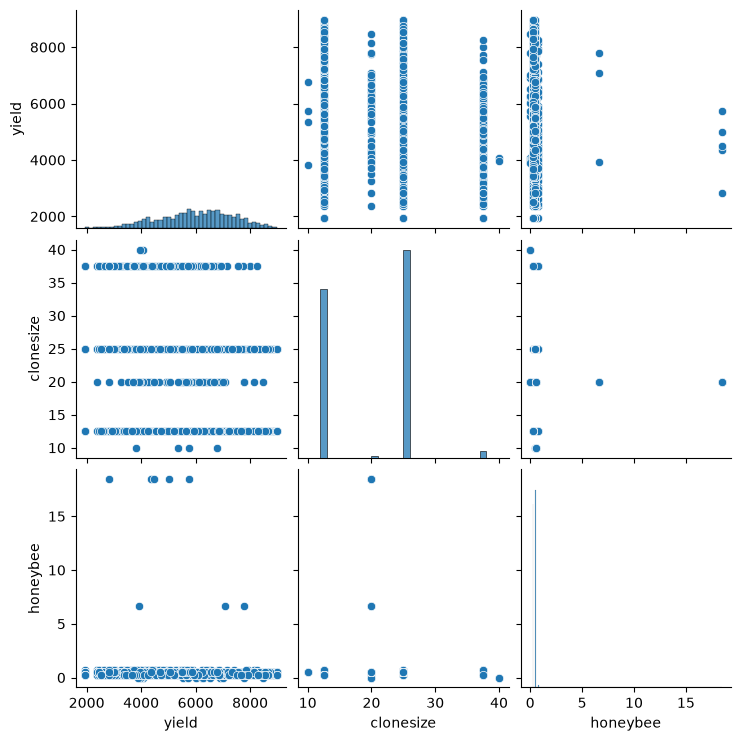

In [64]:
# Check the assumptions of Linear Regression
sns.pairplot(train[["yield", "clonesize", "honeybee"]])
plt.show()

## Train the model

In [42]:
model = LinearRegression() # the model doesnt know anything now

'''
.fit() - train the model using the data
find the patterns that connect the features(X_train) to the target(y_train)
store the knowledge inside the model
'''
model.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[ -4.41, -0.9 , 323.57,...,11642. ,-7262.29, 137.14]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](16,)","['clonesize','honeybee','bumbles',...,'fruitset','fruitmass','seeds']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1112
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(16)


what the output shows :

clonesize (-4.41) means keeping every other feature constant increasing clonesize by 1 unit 
decreases the predicted yield by about 4.41 units
    
Increasing Fruit Set by one unit increases predicted Yield by roughly 11642 - has a very strong effect on the output of the model


# insight

>Why does fruitmass have a strong positive correlation in the heatmap and negative correlation while training the model?

While the heatmap indicates that fruitmass is positively associated with yield, Linear Regression considers all features together. Because fruitset and fruitmass contain similar information, the model attributes most of the increase in yield to fruitset. After accounting for fruitset, fruitmass provides little unique information, resulting in a negative coefficient due to multicollinearity.


## Predictions

In [43]:
# use the learned patterns to estimate the yield for new data 
# recall X_valid doesnt contain yield column
y_pred = model.predict(X_valid)

## Regression Metrics

### Mean Absolute Error MAE

In [45]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_valid,y_pred)
print("MAE :" , mae)


MAE : 370.4475274528586


the model predicted the yield differs from the catual yield by 370.45
an average error of 370.45 is small compared to the overall range of yield values 
the predictions are relatively close to the actual yields 

### RMSE

In [50]:
from sklearn.metrics import root_mean_squared_error , mean_squared_error
rmse = np.sqrt(mean_squared_error(y_valid,y_pred))
print("RMSE", rmse)


RMSE 577.2086172037132


The model achieved an RMSE of 577.20. Since RMSE penalizes large prediction errors more heavily than MAE, the higher RMSE compared with the MAE indicates that while most predictions are reasonably accurate, the model occasionally produces larger errors for certain farms.

### R-Squared

In [51]:
from sklearn.metrics import r2_score
r2 = r2_score(y_valid,y_pred)
print ("R^2 score:", r2)


R^2 score: 0.8104766968969609


The Linear Regression model achieved an R² score of 0.80, indicating that approximately 80% of the variation in blueberry yield is explained by the predictor variables included in the model. This suggests that the model captures the overall relationship between the features and yield effectively, although approximately 20% of the variation remains unexplained.

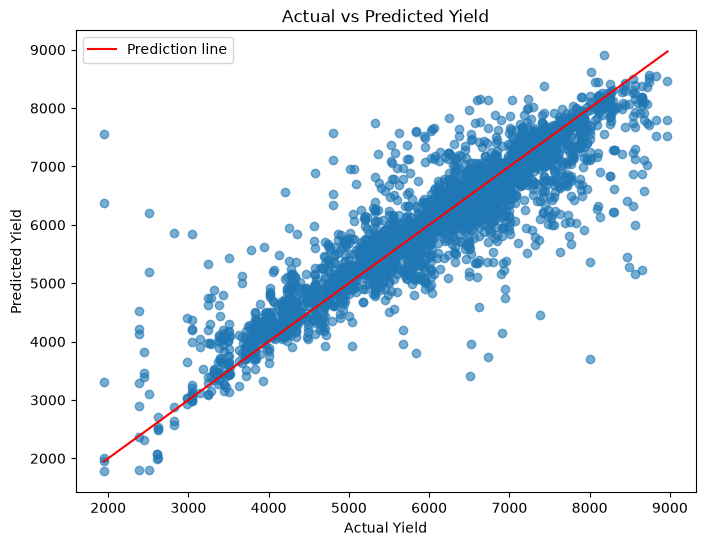

In [54]:
plt.figure(figsize=(8,6))

plt.scatter(y_valid, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot([y_valid.min(), y_valid.max()],
         [y_valid.min(), y_valid.max()],
         color="red",
         linestyle="-",
         label="Prediction line")

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")

plt.legend()

plt.show()

The Actual vs Predicted scatter plot compares the model's predicted blueberry yields with the observed yields in the validation dataset. The  red line represents perfect predictions, where predicted values equal the actual values. Most data points lie close to this line, indicating that the Linear Regression model predicts yield with good accuracy. However, several points are farther from the line, corresponding to larger prediction errors, which is consistent with the higher RMSE value. Overall, the distribution of points suggests that the model captures the general relationship between the predictor variables and blueberry yield effectively.

## Train the final model

In [56]:
model.fit(X,y) # using 100% of the data 


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[ -4.5 , -2.2 , 370.17,...,11776.19,-7426.38, 136.38]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](16,)","['clonesize','honeybee','bumbles',...,'fruitset','fruitmass','seeds']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1132
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(16)


In [59]:
predictions = model.predict(X_test)
submission = pd.DataFrame({
    'id' : test["id"],
    'yield' : predictions
})

In [61]:
submission.to_csv(r'C:\Users\HAZEL\Desktop\Machine_Learning\data\submission.csv', index=False)

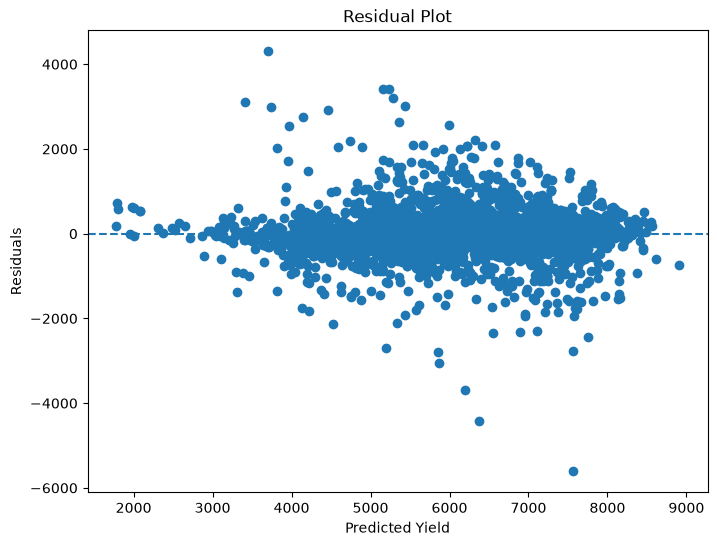

In [63]:
# Residual plot
residuals = y_valid - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()